In [1]:
import polars as pl
import matplotlib.pyplot as plt
SALES_FILE_PATH = "..\\data\\silver\\sales.parquet"

sales_df = pl.scan_parquet(SALES_FILE_PATH)
sales_df.show()



id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
str,str,str,str,str,str,str,i64,str,i64,str,i64,i64,i64,str,str,str,str,i64,i64,i64,f64
"""HOBBIES_1_238_CA_1_evaluation""","""HOBBIES_1_238""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",1,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,5.94
"""HOBBIES_1_266_CA_1_evaluation""","""HOBBIES_1_266""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null
"""HOBBIES_1_272_CA_1_evaluation""","""HOBBIES_1_272""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null
"""HOBBIES_1_275_CA_1_evaluation""","""HOBBIES_1_275""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null
"""HOBBIES_1_284_CA_1_evaluation""","""HOBBIES_1_284""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null


In [2]:
result = (
    sales_df
    .select([
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "year",
        'date',
        "sales",
        "sell_price"
    ])
    .group_by([
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "year",
        "date"
    ])
    .agg([
        pl.sum("sales").alias("daily_sales"),
        pl.mean("sell_price").alias("avg_sell_price")
    ])
    .sort([
        "item_id",
        "store_id",
        "date"
    ])
)

result_df = result.collect()

In [3]:
result_df

item_id,dept_id,cat_id,store_id,year,date,daily_sales,avg_sell_price
str,str,str,str,i64,str,i64,f64
"""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""",2011,"""2011-01-29""",3,2.0
"""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""",2011,"""2011-01-30""",0,2.0
"""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""",2011,"""2011-01-31""",0,2.0
"""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""",2011,"""2011-02-01""",1,2.0
"""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""",2011,"""2011-02-02""",4,2.0
…,…,…,…,…,…,…,…
"""HOUSEHOLD_2_516""","""HOUSEHOLD_2""","""HOUSEHOLD""","""WI_3""",2016,"""2016-05-18""",0,5.94
"""HOUSEHOLD_2_516""","""HOUSEHOLD_2""","""HOUSEHOLD""","""WI_3""",2016,"""2016-05-19""",0,5.94
"""HOUSEHOLD_2_516""","""HOUSEHOLD_2""","""HOUSEHOLD""","""WI_3""",2016,"""2016-05-20""",0,5.94


In [4]:
daily_summary = (
    result_df
    .group_by(["year", "date"])
    .agg([
        pl.sum("daily_sales").alias("total_daily_sales"),
        pl.mean("avg_sell_price").alias("daily_avg_price")
    ])
    .sort("date")
)

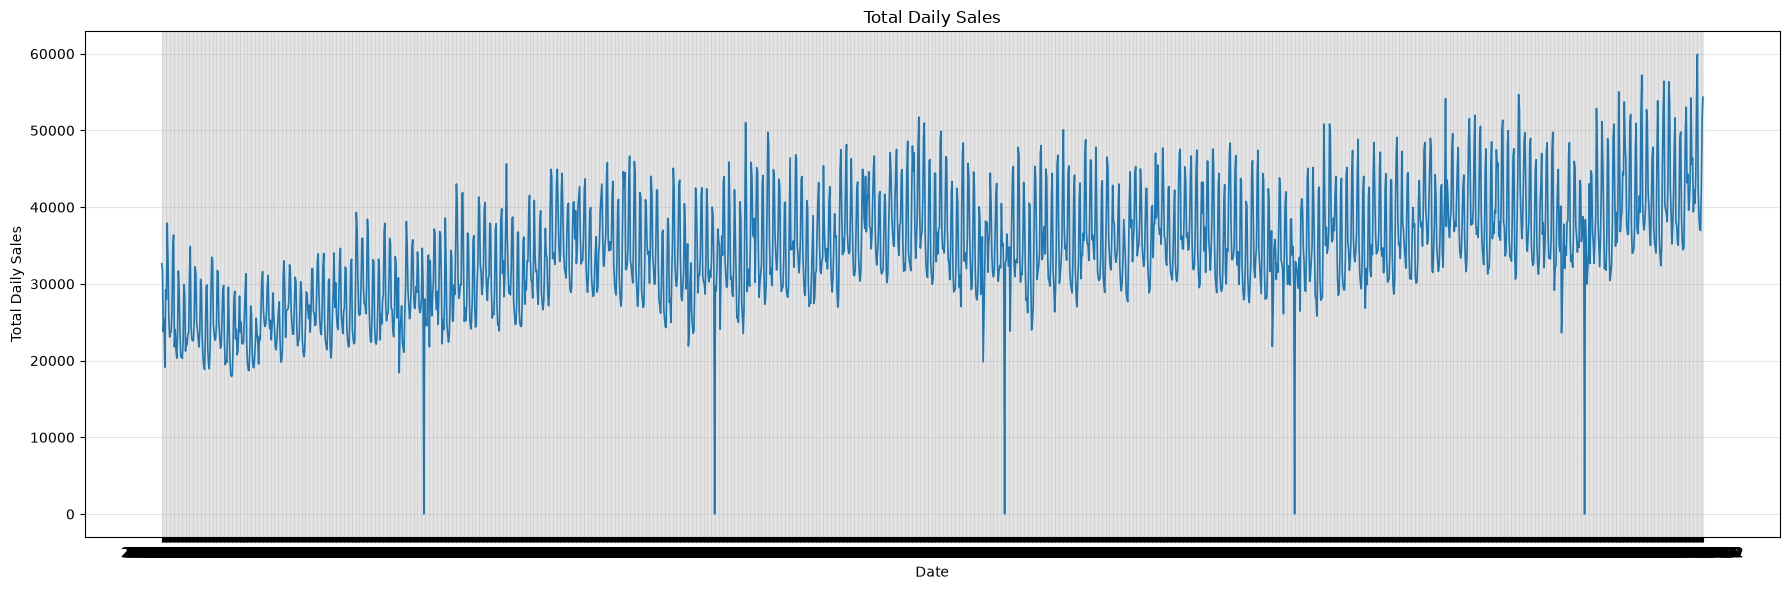

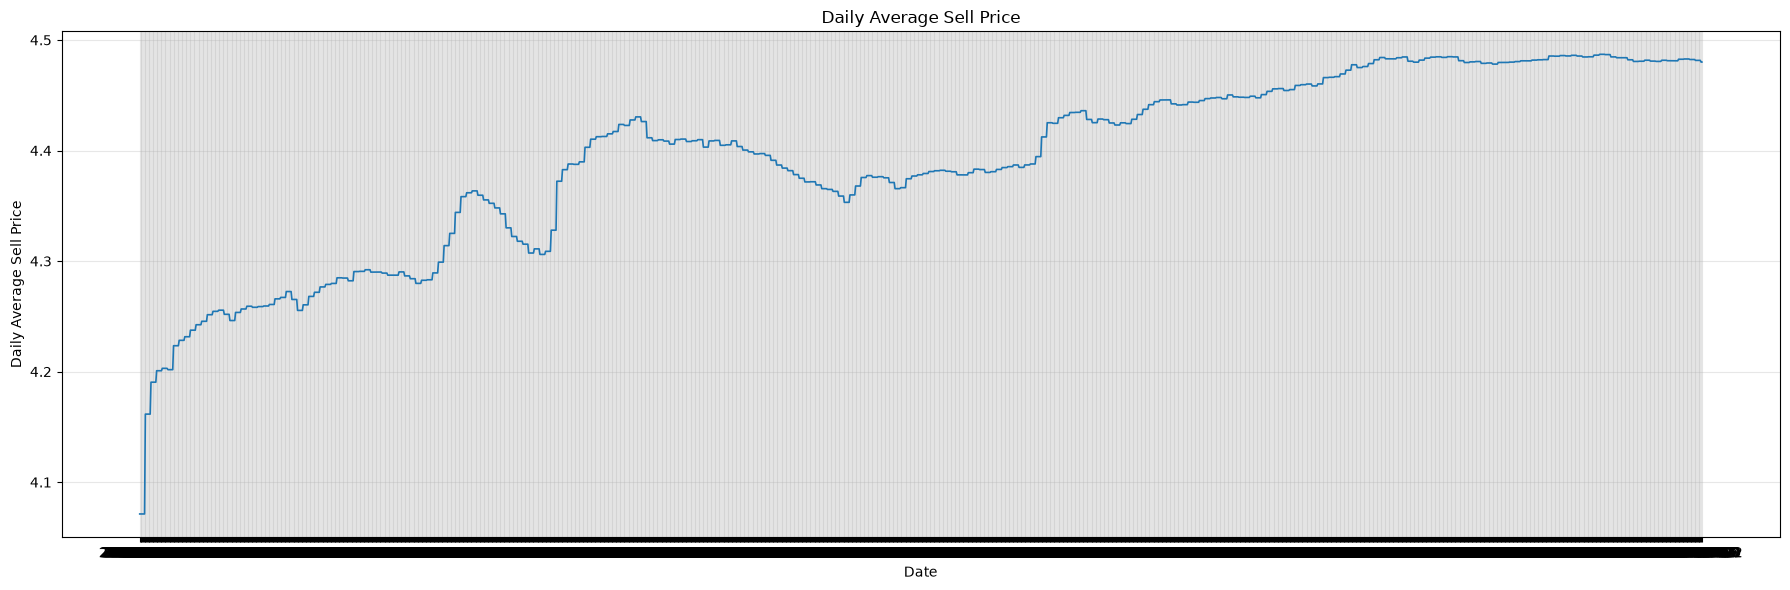

In [ ]:

# Daily total sales
plt.figure(figsize=(18, 6))

plt.plot(
    daily_summary["date"].to_numpy(),
    daily_summary["total_daily_sales"].to_numpy(),
    linewidth=1.2
)

plt.xlabel("Date")
plt.ylabel("Total Daily Sales")
plt.title(f"Total Daily Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Daily average price
plt.figure(figsize=(18, 6))

plt.plot(
    daily_summary["date"].to_numpy(),
    daily_summary["daily_avg_price"].to_numpy(),
    linewidth=1.2
)

plt.xlabel("Date")
plt.ylabel("Daily Average Sell Price")
plt.title(f"Daily Average Sell Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


ts_df = (
    daily_summary
    .select([
        "date",
        "total_daily_sales",
        "daily_avg_price"
    ])
    .sort("date")
    .to_pandas()
)

ts_df["date"] = pd.to_datetime(ts_df["date"])

ts_df = ts_df.set_index("date")

# Ensure one observation per day
ts_df = ts_df.asfreq("D")

ts_df.head()


,total_daily_sales,daily_avg_price
date,,
2011-01-29,32631,4.071247
2011-01-30,31749,4.071247
2011-01-31,23783,4.071247
2011-02-01,25412,4.071247
2011-02-02,19146,4.071247


In [8]:
ts_df.isna().sum()

total_daily_sales    0
daily_avg_price      0
dtype: int64

In [9]:
# Sales: if a missing date really means no recorded sales
sales_ts = ts_df["total_daily_sales"].fillna(0)

# Price: interpolate missing average prices
price_ts = (
    ts_df["daily_avg_price"]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

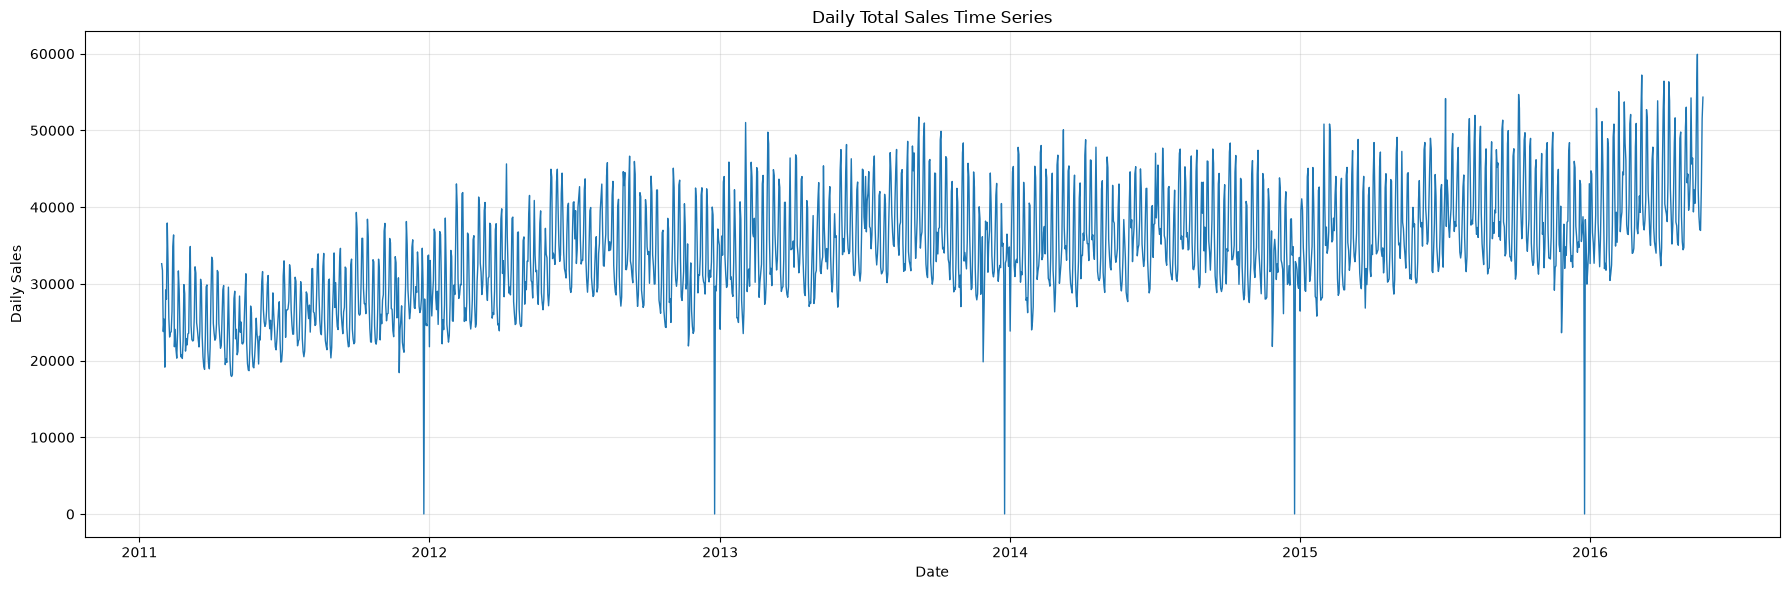

In [10]:
plt.figure(figsize=(18, 6))

plt.plot(
    sales_ts.index,
    sales_ts.values,
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.title("Daily Total Sales Time Series")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

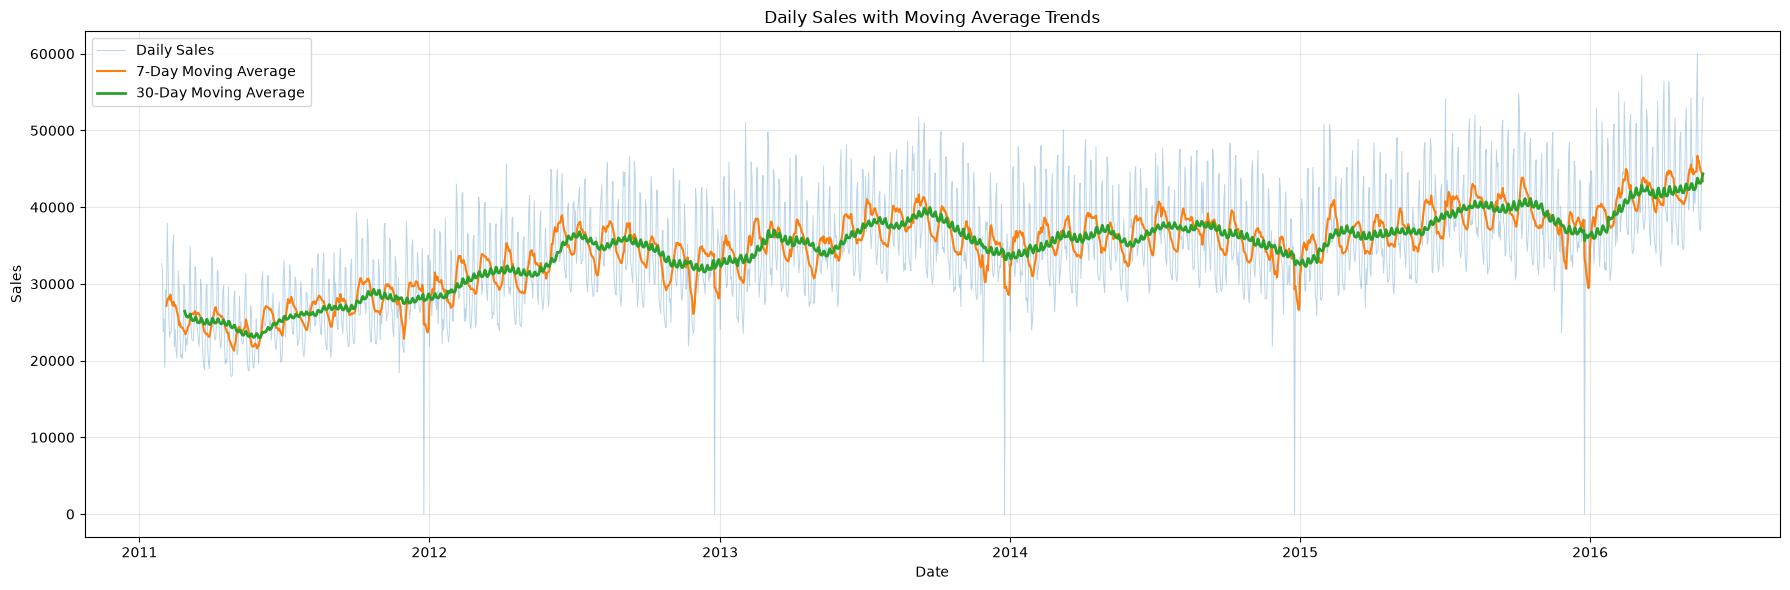

In [11]:
sales_7d = sales_ts.rolling(window=7).mean()
sales_30d = sales_ts.rolling(window=30).mean()

plt.figure(figsize=(18, 6))

plt.plot(
    sales_ts.index,
    sales_ts,
    alpha=0.3,
    linewidth=0.7,
    label="Daily Sales"
)

plt.plot(
    sales_7d.index,
    sales_7d,
    linewidth=1.5,
    label="7-Day Moving Average"
)

plt.plot(
    sales_30d.index,
    sales_30d,
    linewidth=2,
    label="30-Day Moving Average"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales with Moving Average Trends")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

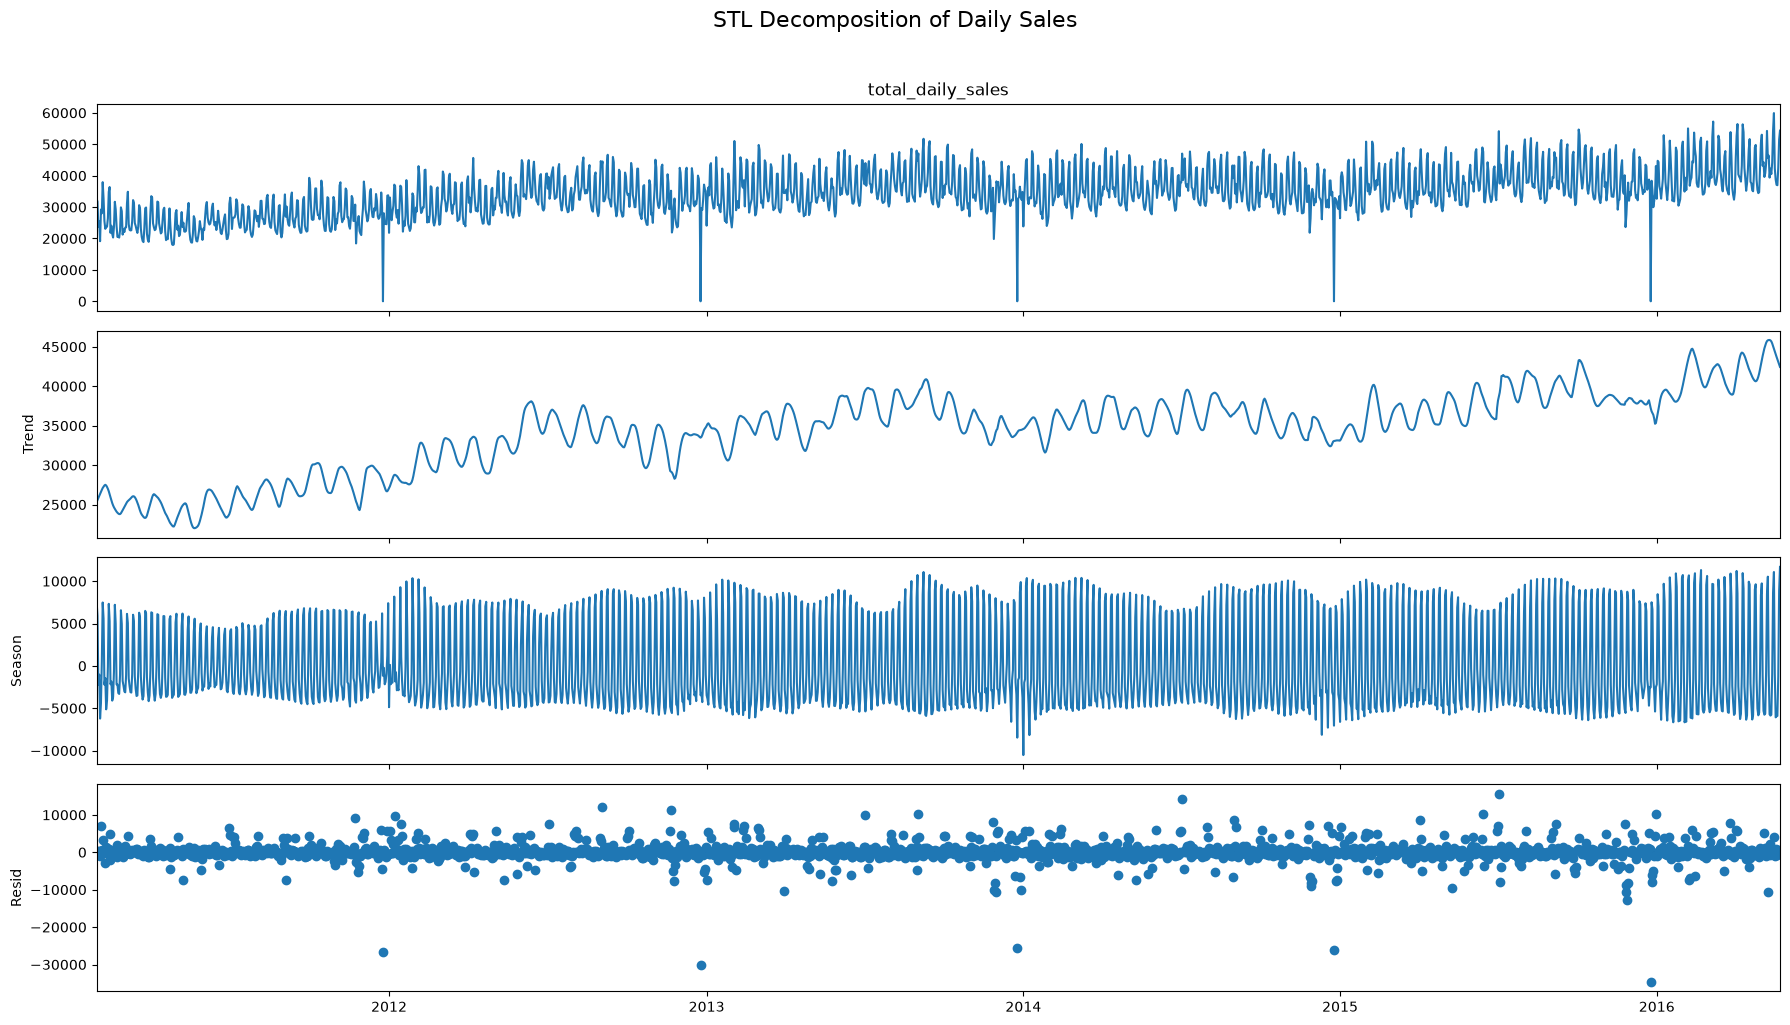

In [12]:
sales_stl = STL(
    sales_ts,
    period=7,
    robust=True
)

sales_result = sales_stl.fit()

sales_result.plot()

plt.gcf().set_size_inches(18, 10)
plt.suptitle(
    "STL Decomposition of Daily Sales",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [13]:
sales_trend = sales_result.trend
sales_seasonal = sales_result.seasonal
sales_residual = sales_result.resid

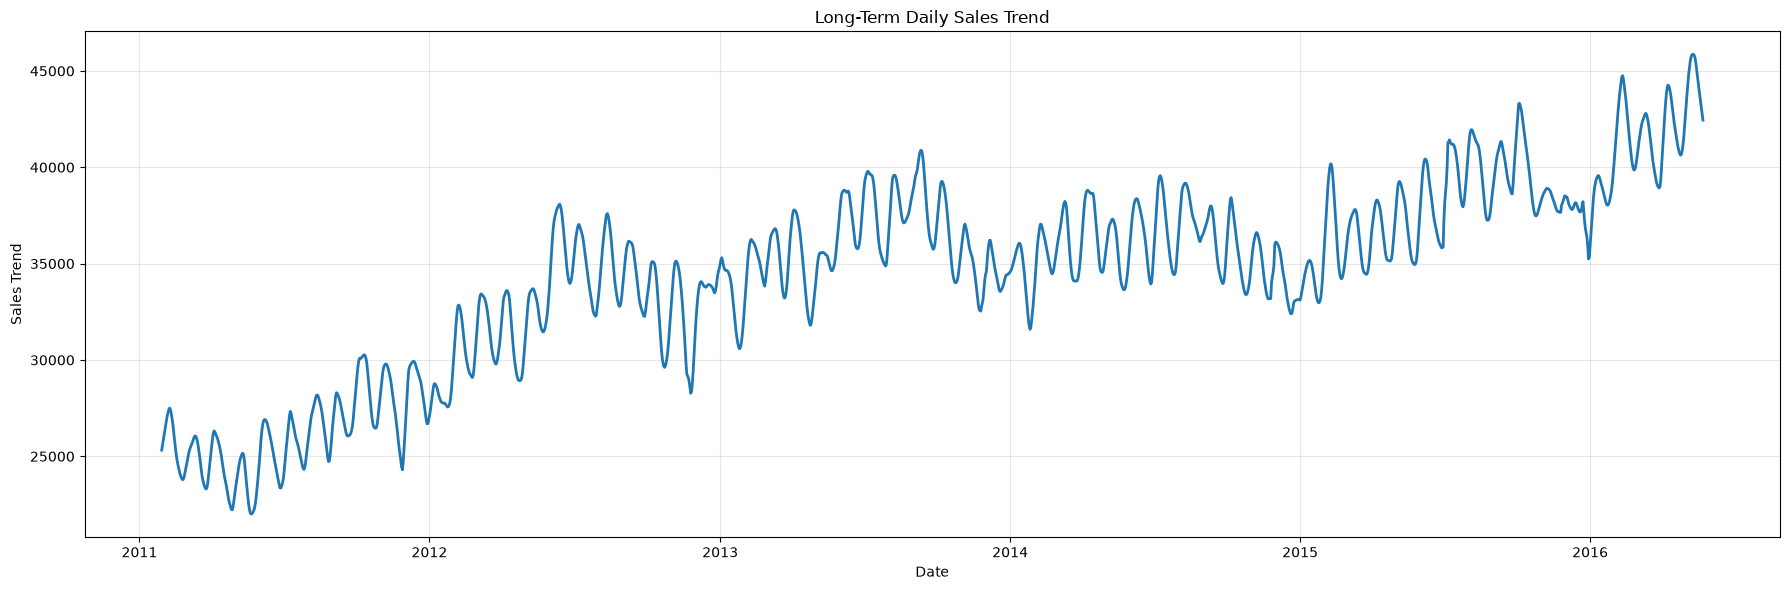

In [14]:
plt.figure(figsize=(18, 6))

plt.plot(
    sales_trend.index,
    sales_trend.values,
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Sales Trend")
plt.title("Long-Term Daily Sales Trend")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

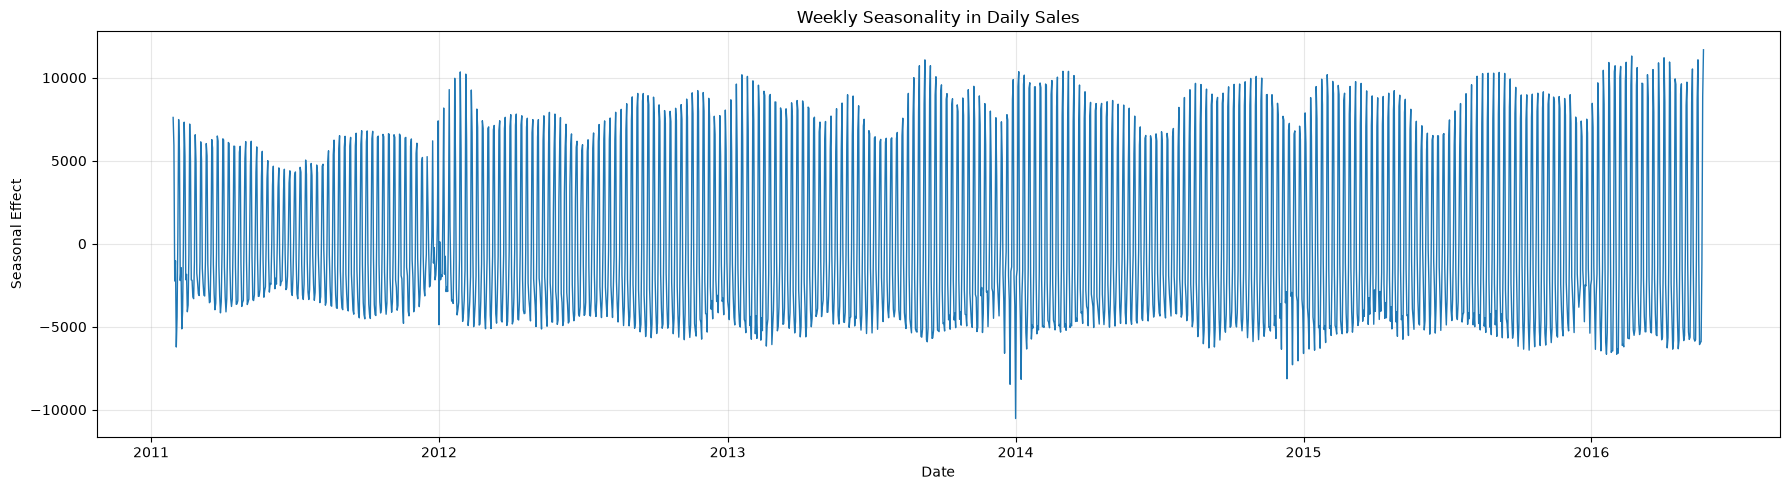

In [15]:
plt.figure(figsize=(18, 5))

plt.plot(
    sales_seasonal.index,
    sales_seasonal.values,
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Seasonal Effect")
plt.title("Weekly Seasonality in Daily Sales")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

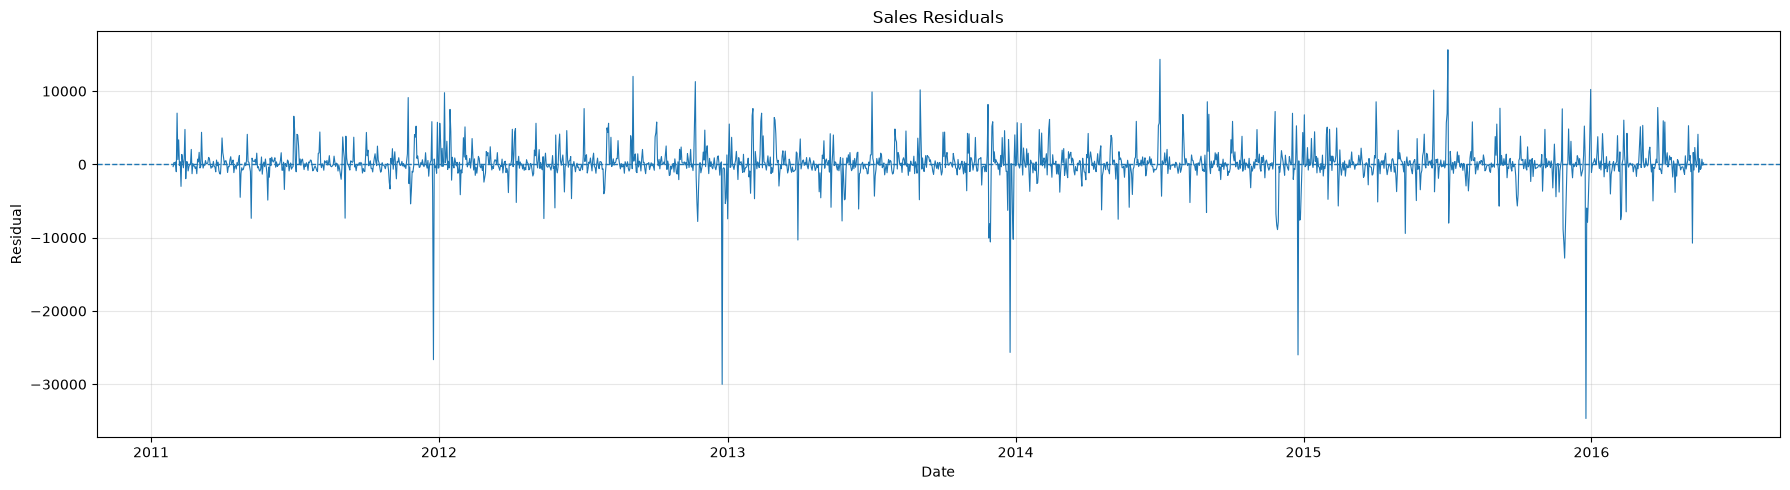

In [16]:
plt.figure(figsize=(18, 5))

plt.plot(
    sales_residual.index,
    sales_residual.values,
    linewidth=0.8
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Sales Residuals")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1600x600 with 0 Axes>

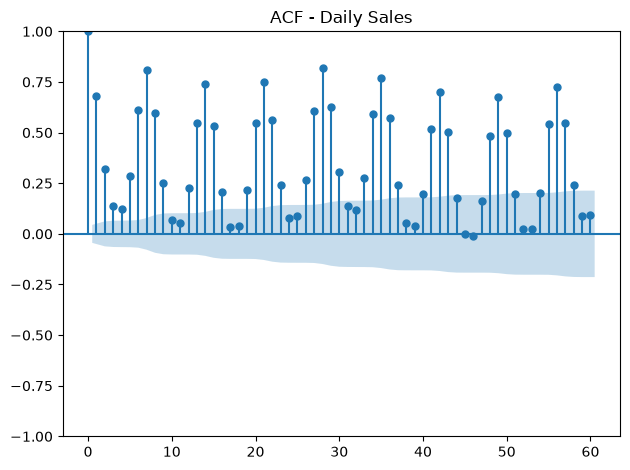

In [17]:
plt.figure(figsize=(16, 6))

plot_acf(
    sales_ts,
    lags=60
)

plt.title("ACF - Daily Sales")
plt.tight_layout()
plt.show()

<Figure size 1600x600 with 0 Axes>

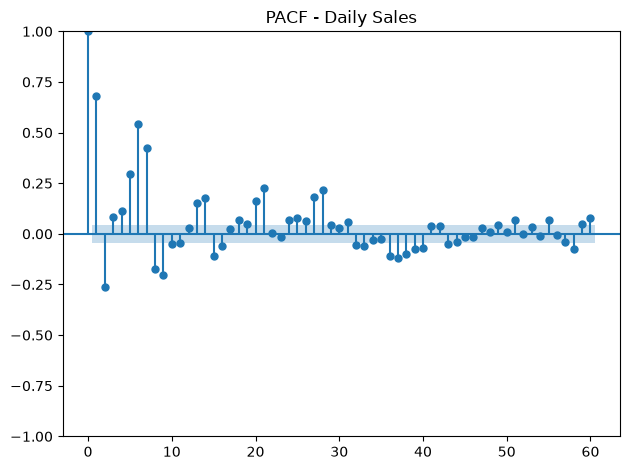

In [18]:
plt.figure(figsize=(16, 6))

plot_pacf(
    sales_ts,
    lags=60,
    method="ywm"
)

plt.title("PACF - Daily Sales")
plt.tight_layout()
plt.show()

In [20]:
adf_result = adfuller(
    sales_ts.dropna()
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")
    
if adf_result[1] < 0.05:
    print("Series appears stationary")
else:
    print("Series appears non-stationary")

ADF Statistic: -1.2960840275853232
p-value: 0.6309619660319115

Critical Values:
1%: -3.4337711555892523
5%: -2.8630512450631986
10%: -2.567574528530358
Series appears non-stationary


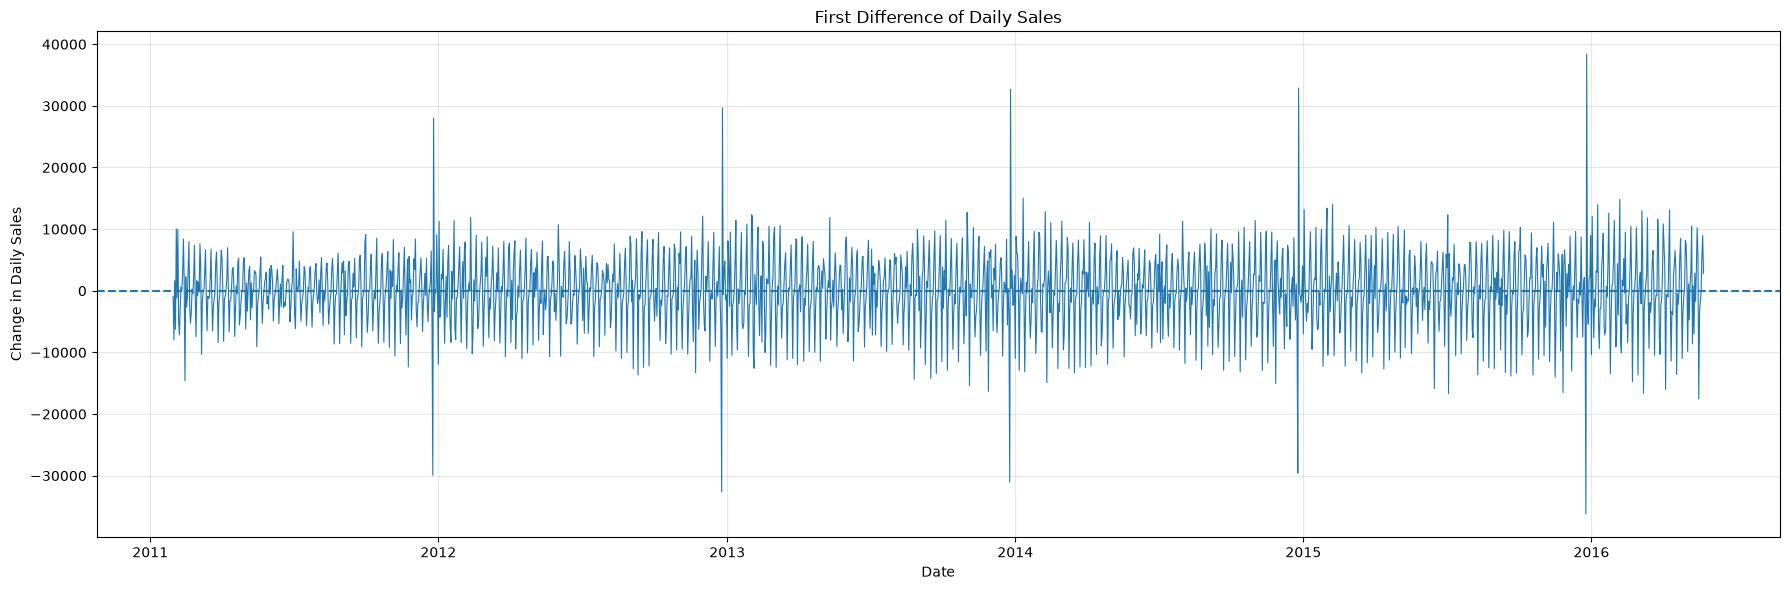

In [21]:
sales_diff = sales_ts.diff().dropna()

plt.figure(figsize=(18, 6))

plt.plot(
    sales_diff.index,
    sales_diff.values,
    linewidth=0.8
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Change in Daily Sales")
plt.title("First Difference of Daily Sales")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
diff_adf = adfuller(sales_diff)

print("ADF Statistic:", diff_adf[0])
print("p-value:", diff_adf[1])

ADF Statistic: -23.638331427812485
p-value: 0.0


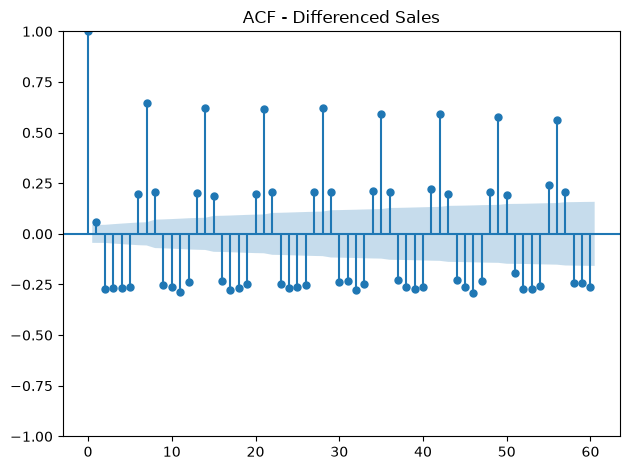

In [23]:
plot_acf(
    sales_diff,
    lags=60
)

plt.title("ACF - Differenced Sales")
plt.tight_layout()
plt.show()

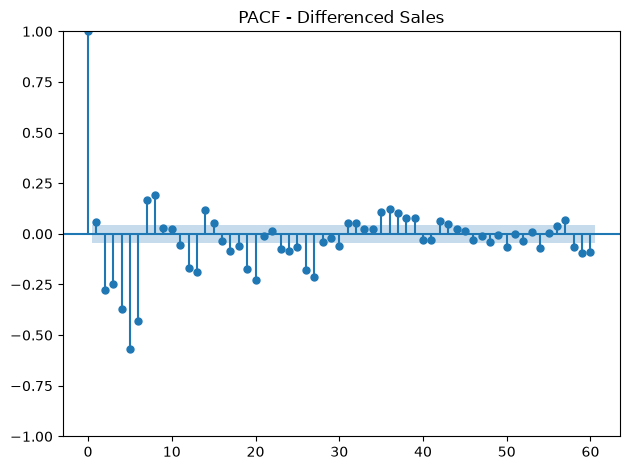

In [24]:
plot_pacf(
    sales_diff,
    lags=60,
    method="ywm"
)

plt.title("PACF - Differenced Sales")
plt.tight_layout()
plt.show()

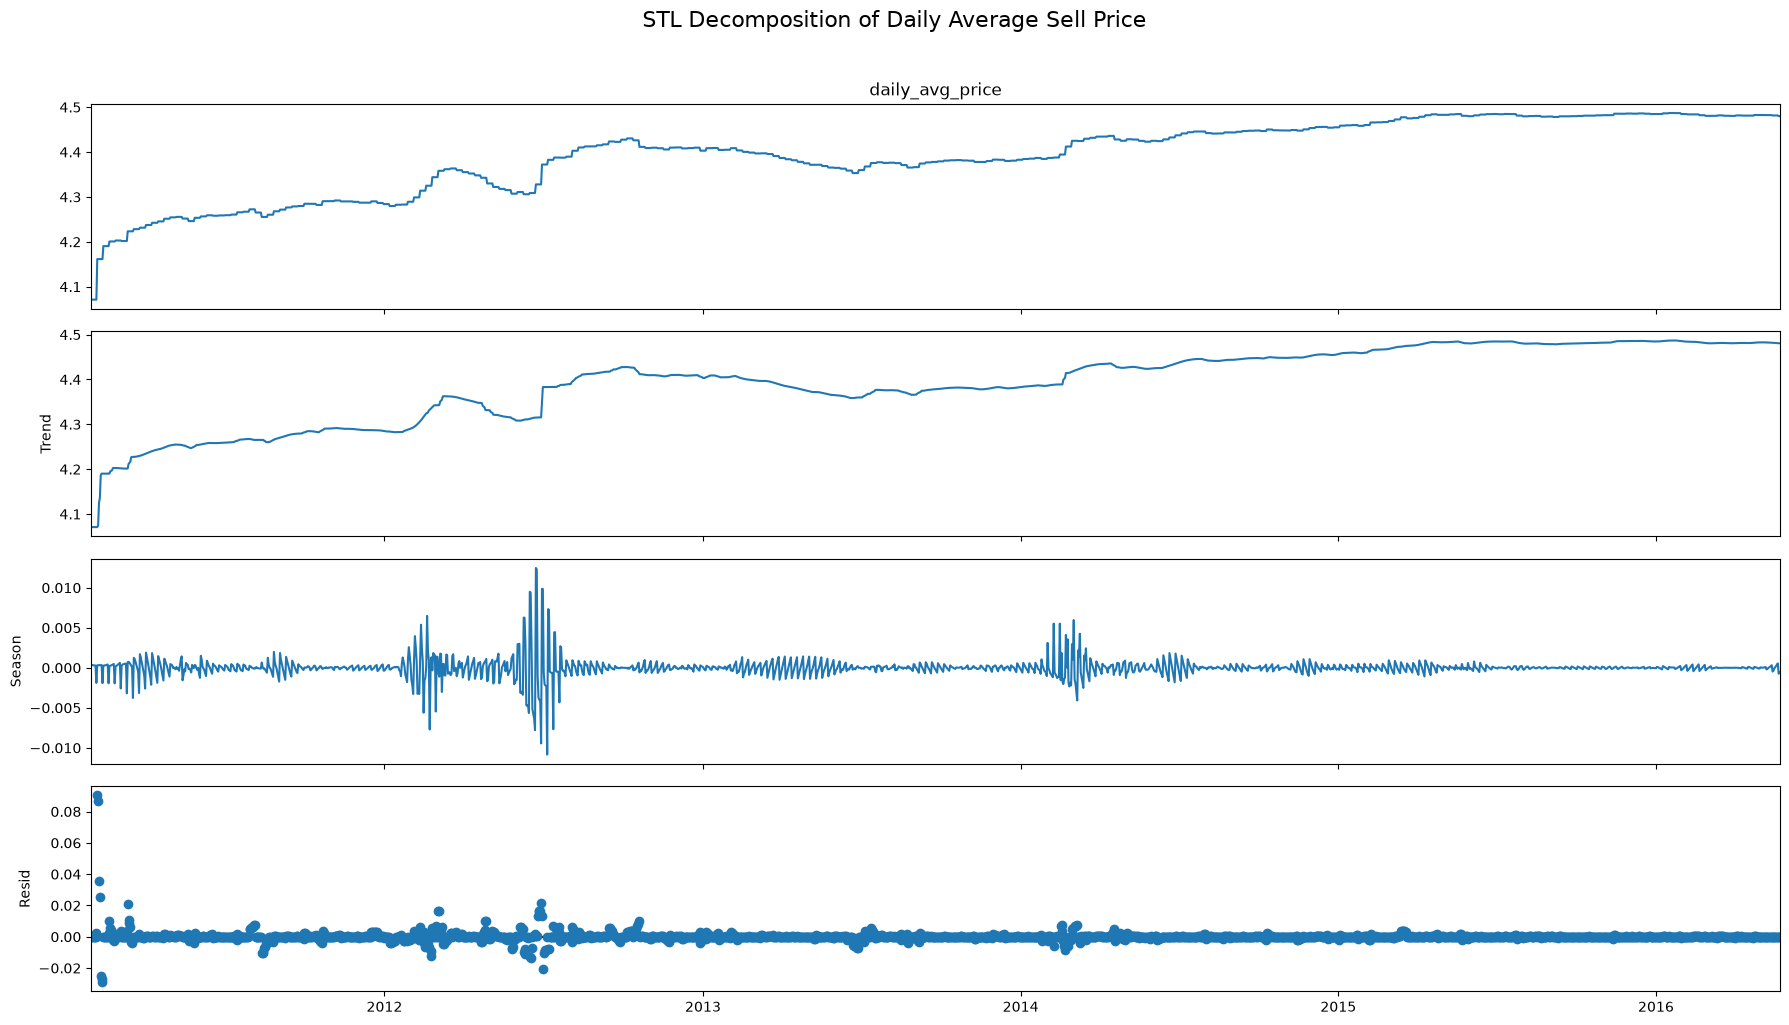

In [26]:
price_stl = STL(
    price_ts,
    period=7,
    robust=True
)

price_result = price_stl.fit()

price_result.plot()

plt.gcf().set_size_inches(18, 10)

plt.suptitle(
    "STL Decomposition of Daily Average Sell Price",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


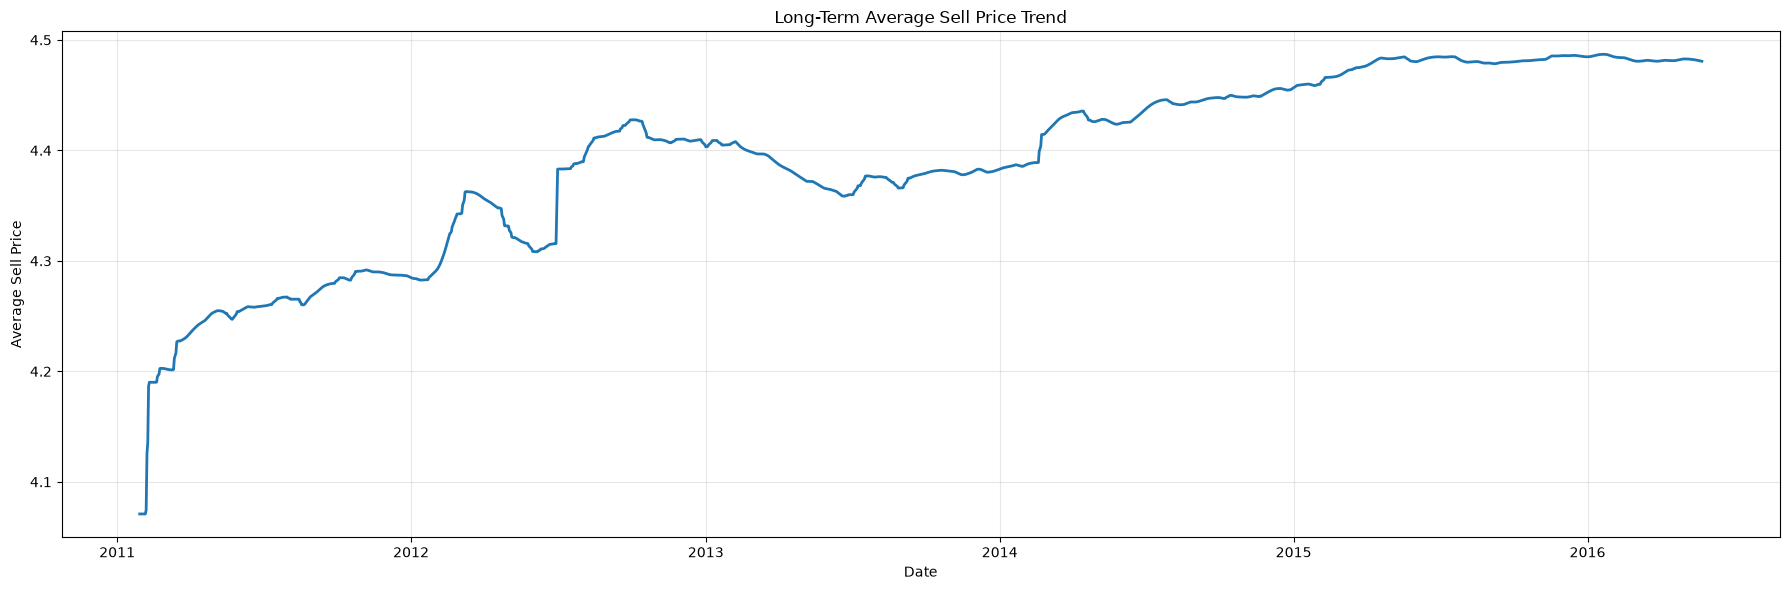

In [27]:
plt.figure(figsize=(18, 6))

plt.plot(
    price_result.trend.index,
    price_result.trend.values,
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Average Sell Price")
plt.title("Long-Term Average Sell Price Trend")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

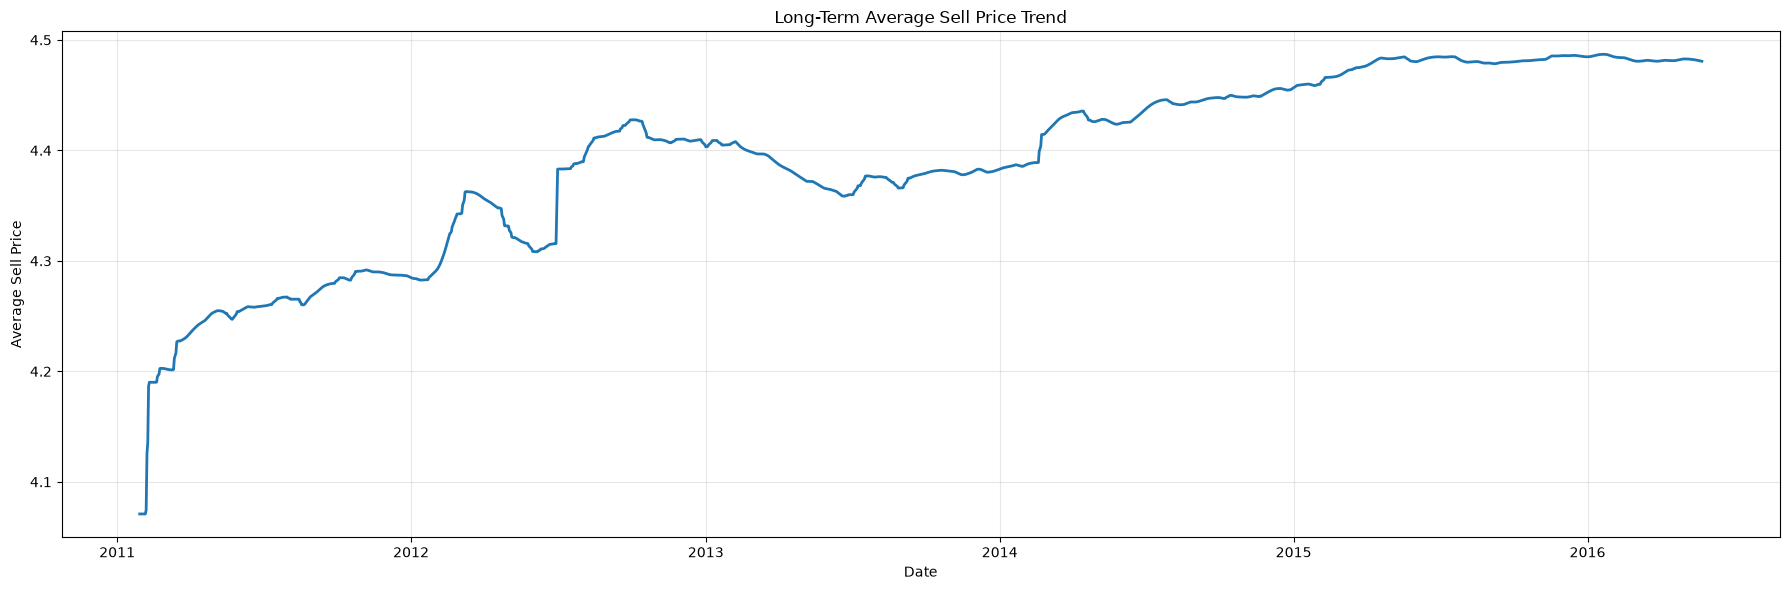

In [28]:
plt.figure(figsize=(18, 6))

plt.plot(
    price_result.trend.index,
    price_result.trend.values,
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Average Sell Price")
plt.title("Long-Term Average Sell Price Trend")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

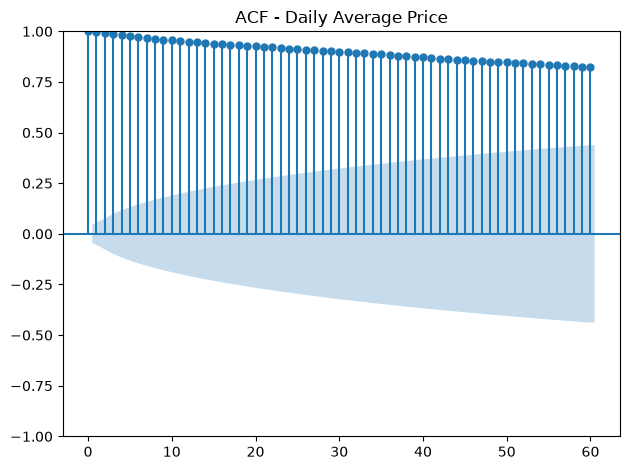

In [29]:
plot_acf(
    price_ts,
    lags=60
)

plt.title("ACF - Daily Average Price")
plt.tight_layout()
plt.show()

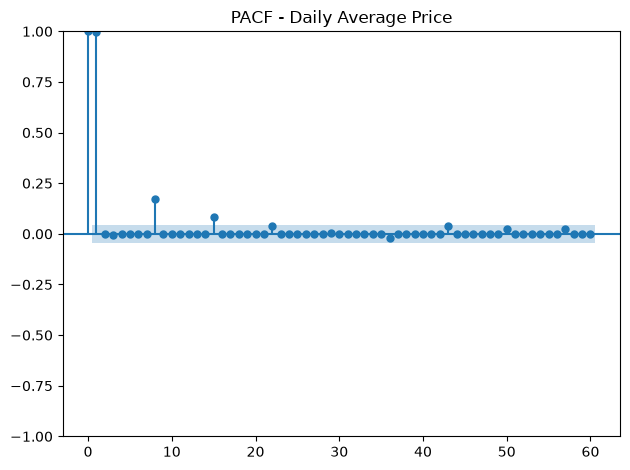

In [30]:
plot_pacf(
    price_ts,
    lags=60,
    method="ywm"
)

plt.title("PACF - Daily Average Price")
plt.tight_layout()
plt.show()

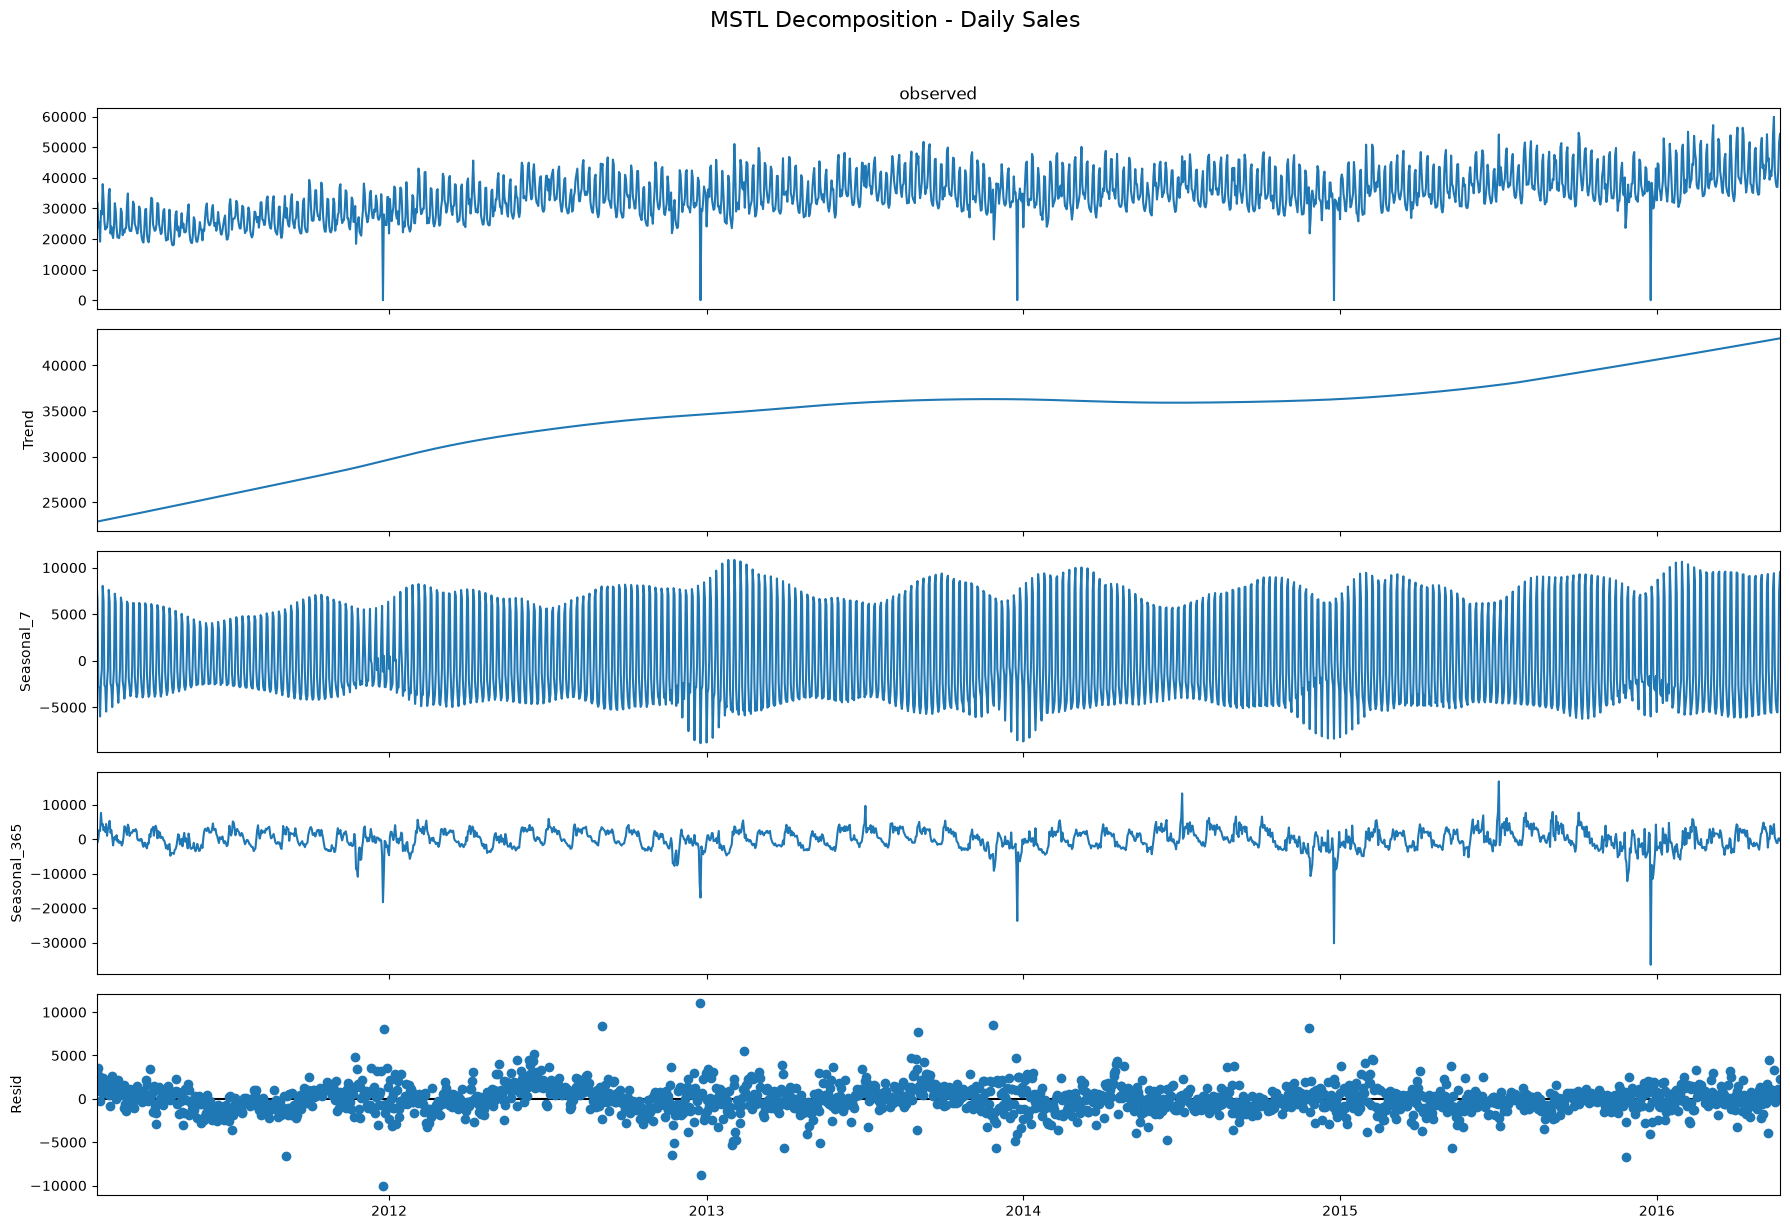

In [31]:
from statsmodels.tsa.seasonal import MSTL

mstl = MSTL(
    sales_ts,
    periods=(7, 365)
)

mstl_result = mstl.fit()

mstl_result.plot()

plt.gcf().set_size_inches(18, 12)
plt.suptitle(
    "MSTL Decomposition - Daily Sales",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()